In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('insurance-checkpoint.csv')

In [3]:
df
df.shape
df.head(10)
df.describe()
df.info()
df.isnull().sum()
df.value_counts()
df.count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA 

In [5]:
df.shape

(1338, 7)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

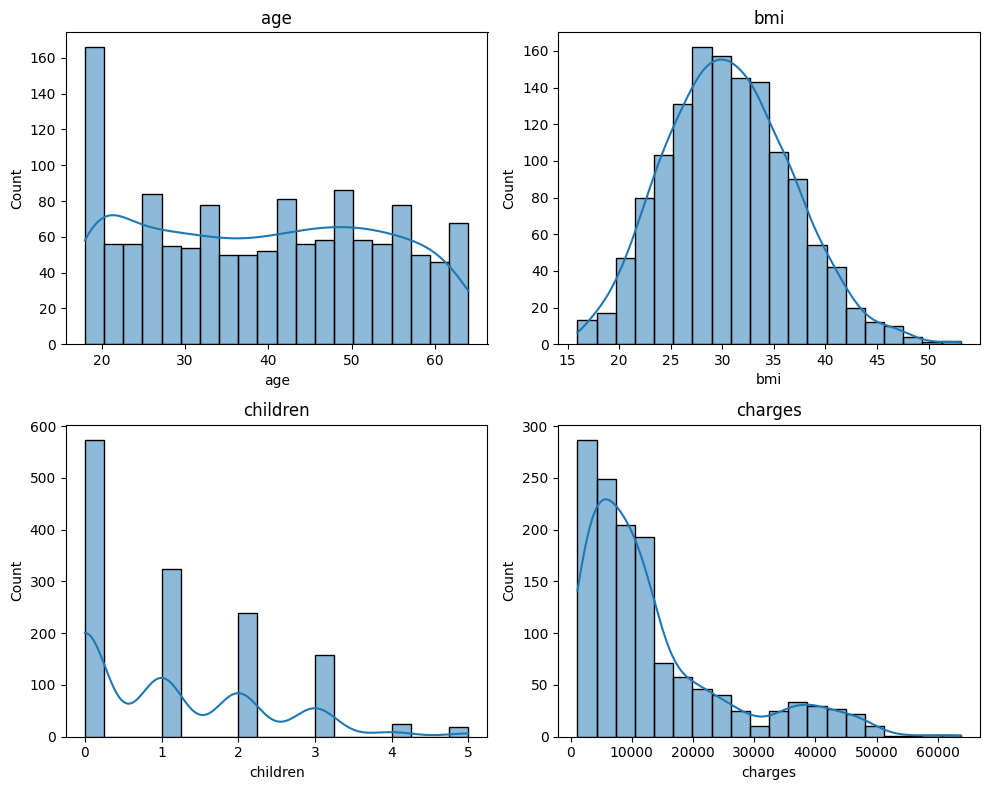

In [11]:
# df.describe() check all numeric value not na categorical
numeric_column =['age','bmi', 'children', 'charges']
fig,axes=plt.subplots(2,2,figsize=(10,8))
axes=axes.flatten()
for i,col in enumerate(numeric_column):
    sns.histplot(df[col],kde=True,bins=20,ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

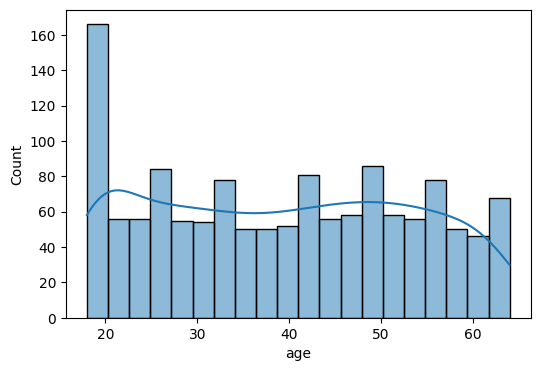

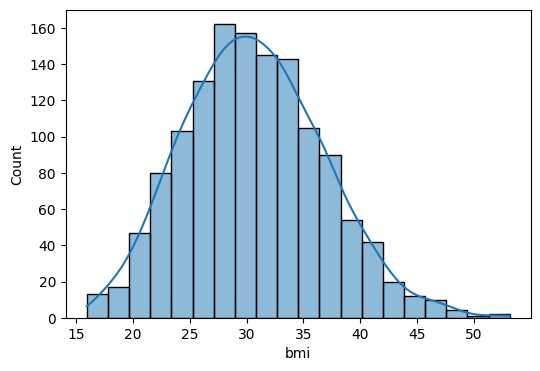

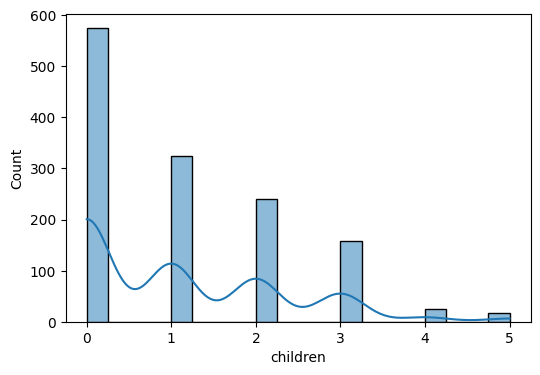

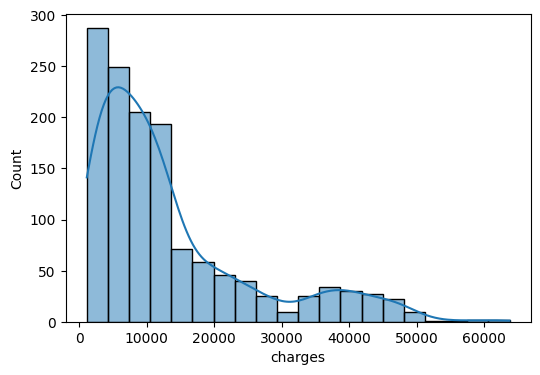

In [12]:
numeric_column =['age','bmi', 'children', 'charges']
for col in numeric_column :
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)


<Axes: xlabel='children', ylabel='count'>

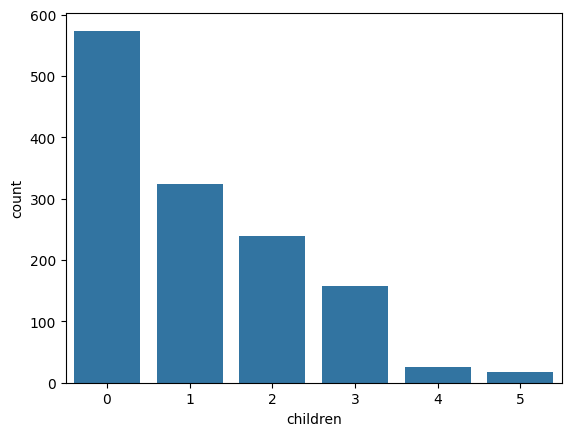

In [13]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

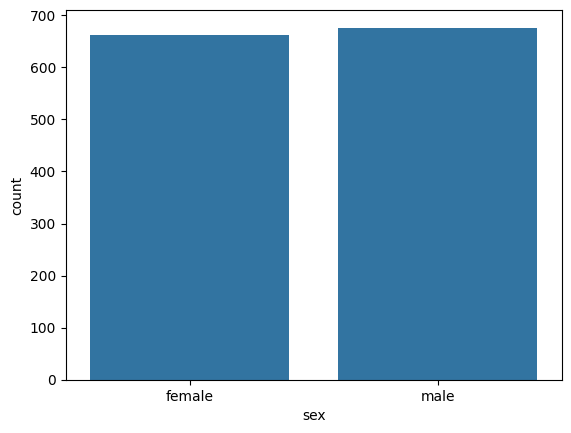

In [14]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

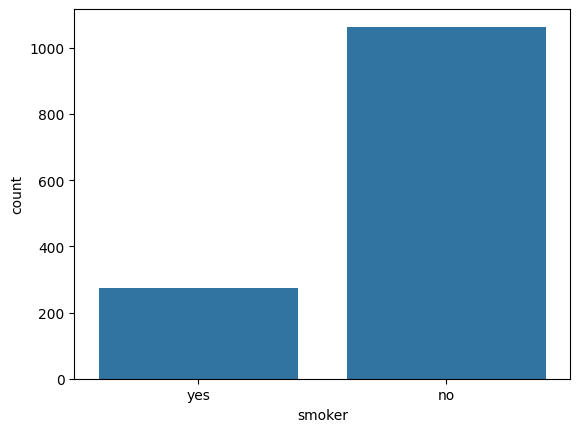

In [15]:
sns.countplot(x=df['smoker'])

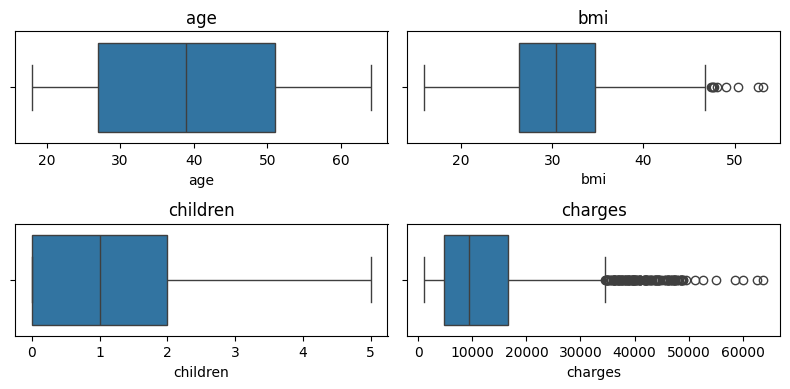

In [16]:
numeric_column =['age','bmi', 'children', 'charges']
fig,axes=plt.subplots(2,2,figsize=(8,4))
axes=axes.flatten()
for i,col in enumerate(numeric_column):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


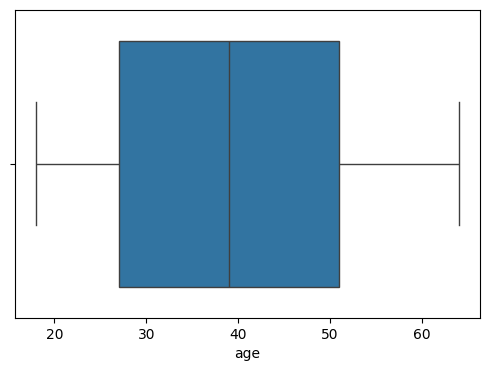

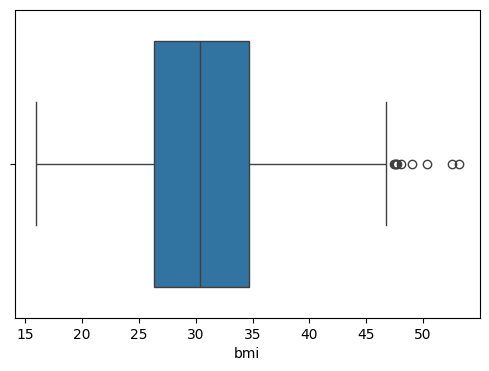

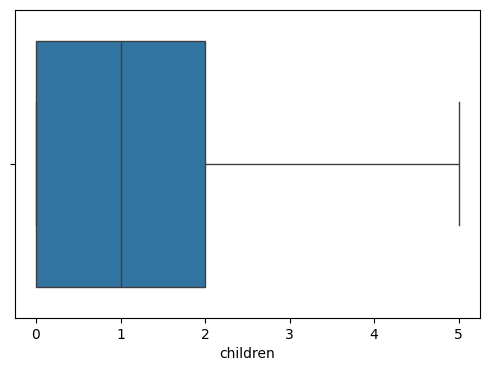

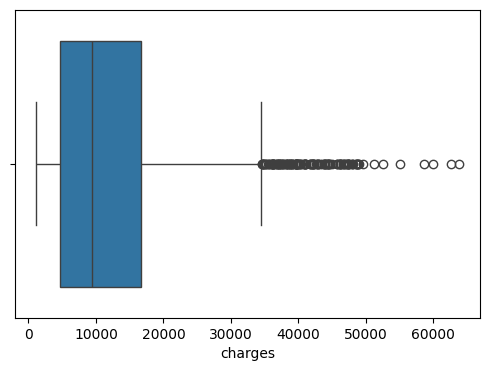

In [17]:
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.boxplot(x =df[col])


<Axes: >

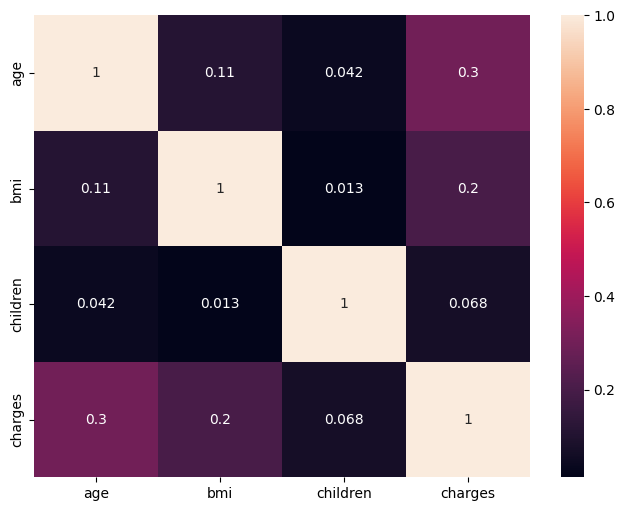

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Cleaning And Processing

In [19]:
df_cleaned =df.copy()

In [20]:
df_cleaned.head()
df_cleaned.isnull().sum()
df_cleaned.shape
df_cleaned.describe()
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.dtypes
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [21]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [22]:
df_cleaned.shape

(1337, 7)

In [23]:
df_cleaned.drop_duplicates(inplace=True)

In [24]:
df_cleaned.shape

(1337, 7)

In [25]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [27]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [28]:
df_cleaned['sex'] =df_cleaned['sex'].map({"male" :0,"female" : 1})


In [29]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [30]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [31]:
# label encoding  ma mutlab hisma onlt two chize ho to aap label encoding use karanga
df_cleaned['smoker'] =df_cleaned['smoker'].map({"yes" : 1,"no" :0})

In [32]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [33]:
df_cleaned.rename(columns={
  'sex':"is_female","smoker" :'is_smoker'  
},inplace=True)


In [34]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [35]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [36]:
# is ma label encoding na karka is ma one hot encoding ka karta ha
# df_cleaned =pd.get_dummies(df_cleaned,columns=['region'],drop_first=True) 

In [37]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [38]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [39]:
df_cleaned=df_cleaned.astype(int)

In [40]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

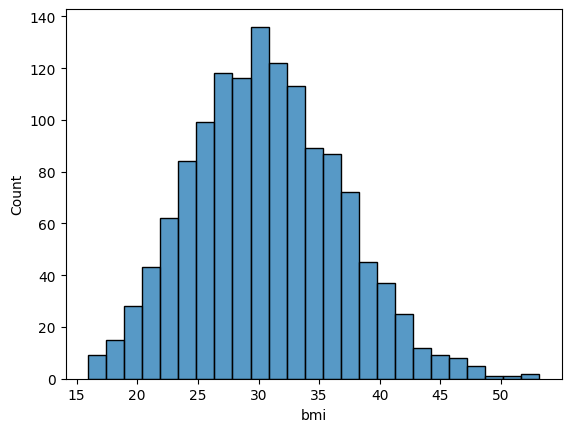

In [41]:
sns.histplot(df['bmi'])

In [42]:
df_cleaned['bmi_category'] =pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','Normal','Overweight','obese']
)

In [43]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [44]:
#  bmi ma da multiple ha ishiliya hum one hot encoding use karanga

In [45]:

df_cleaned=pd.get_dummies(df_cleaned,columns =['bmi_category'],drop_first=True)

In [46]:
df_cleaned =df_cleaned.astype(int)

In [47]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [48]:
# Feature Scalling

df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_obese'],
      dtype='object')

In [57]:
# SK learn = standard sklearn is a liberary
from sklearn.preprocessing import StandardScaler

Cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[Cols] = scaler.fit_transform(df_cleaned[Cols])


In [58]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese,charges_bin
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0,3
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0,3
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0,0


In [51]:
from scipy.stats import pearsonr

# -----------------------------------
# PEarson Correlation Calculation 
# ------------------------------------

# Length of features to check against target

selected_feature =[
    'age','is_female','bmi','children','is_smoker','region_northwest',
    'region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight',
    'bmi_category_obese'
]

correlation = {
    feature : pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_feature
}

correlation_df =pd.DataFrame(list(correlation.items()),columns=['Feature','person correlation'])
correlation_df.sort_values(by='person correlation',ascending=False)



,Feature,person correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_Normal,-0.104042


In [52]:
cat_feature =['is_female','is_smoker','region_northwest',
    'region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight',
    'bmi_category_obese'
    
]

In [53]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha =0.05

df_cleaned['charges_bin'] =pd.qcut(df_cleaned['charges'],q=4,labels=False)
chi2_results ={}

for col in cat_feature:
    contigency =pd.crosstab(df_cleaned[col],df_cleaned['charges_bin'])
    chi2_stat,p_val, _, _ =chi2_contingency(contigency)
    decision ='Reject Null  (Keep Feature)'if p_val <alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] ={
        'chi2_statistic':chi2_stat,
        'p_value' : p_val,
        'Decision':decision
        }
    
chi2_df =pd.DataFrame(chi2_results).T
chi2_df =chi2_df.sort_values(by ='p_value')
chi2_df


,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [54]:
final_df= df_cleaned[[ 'age','is_female','bmi','children','is_smoker','region_northwest',
    'region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight',
    'bmi_category_obese']]

In [55]:
final_df

,age,is_female,bmi,children,is_smoker,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,0,0,1,0,1,0


In [56]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
